**Promblem Statement**

To analyze and forecast EV sales trends across different states in India, identifying high-growth regions and key demand patterns to support data-driven decision making.

**Importing the Library**

In [77]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

**Loading the data**

In [78]:
saledf = pd.read_csv('/content/EV_Dataset.csv')

In [79]:
saledf.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [80]:
#checking the null values
saledf.isnull().sum()

,0
Year,0
Month_Name,0
Date,0
State,0
Vehicle_Class,0
Vehicle_Category,0
Vehicle_Type,0
EV_Sales_Quantity,0


In [81]:
#checking the duplicate values
saledf.duplicated().sum()

np.int64(0)

In [82]:
saledf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


**Converting the data types**

In [83]:
saledf['Date'] = pd.to_datetime(saledf['Date'])

In [84]:
saledf['EV_Sales_Quantity'] = saledf['EV_Sales_Quantity'].astype(int)

In [85]:
saledf['Year'] = saledf['Year'].astype(int)

In [86]:
saledf['EV_Sales_Quantity'].describe()

,EV_Sales_Quantity
count,96845.000000
mean,37.108896
std,431.566675
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,20584.000000


In [87]:
(saledf['EV_Sales_Quantity'] == 0).sum()

np.int64(82783)

<Axes: xlabel='EV_Sales_Quantity', ylabel='Count'>

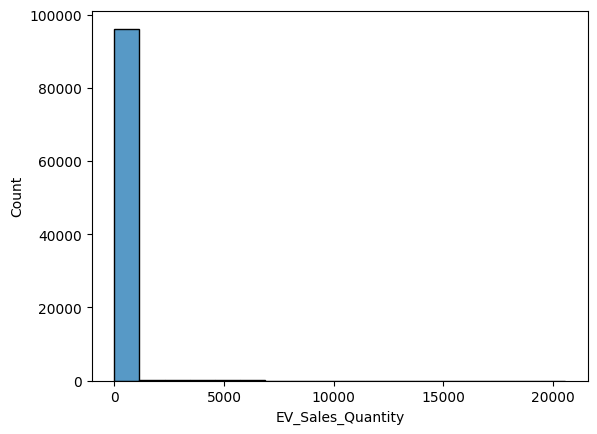

In [88]:
sns.histplot(saledf['EV_Sales_Quantity'])

<Axes: xlabel='Year'>

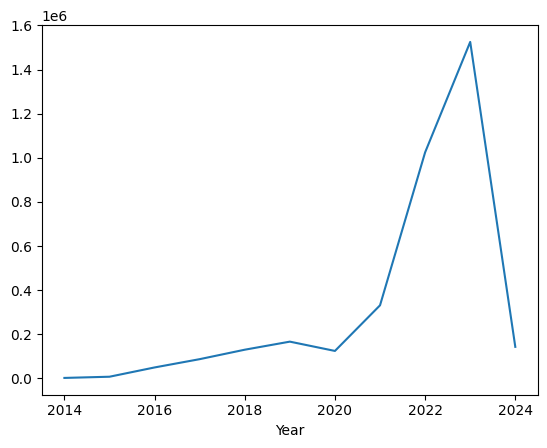

In [89]:
saledf.groupby('Year')['EV_Sales_Quantity'].sum().plot()

In [90]:
a=saledf.groupby(
    ['Year', 'Month_Name'],
    as_index=False
)['EV_Sales_Quantity'].sum()
a.tail()

,Year,Month_Name,EV_Sales_Quantity
116,2023,may,158131
117,2023,nov,152610
118,2023,oct,139232
119,2023,sep,127793
120,2024,jan,143182




1. The dataset is highly zero-inflated, with approximately 85% of observations having 0 EV sales . This occurs because sales are recorded for each combination of State, Vehicle Category, and Vehicle Type on a given date.
2. The EV sales distribution is highly right-skewed. High sales values occur in later years due to increasing EV adoption, therefore these values were not treated as outliers.
3. The dataset contains partial data for 2024 (January only), therefore it was excluded from the analysis to avoid bias in trend modeling.



In [91]:
saledf = saledf[saledf['Year'] != 2024]
saledf.shape

(95985, 8)

Insights

In [92]:
daily_sales = saledf.groupby('Date')['EV_Sales_Quantity'].sum().reset_index()
daily_sales['Rolling_Mean'] = daily_sales['EV_Sales_Quantity'].rolling(30).mean()

plt.figure(figsize=(10,8))
fig=px.line(
    daily_sales,
    x='Date',
    y='EV_Sales_Quantity',
    title='Rapid Growth in EV Sales in India'
)
fig.add_scatter(
    x=daily_sales['Date'],
    y=daily_sales['Rolling_Mean'],
    mode='lines',
    name='30-Day Trend',
    line=dict(dash='dash')
)

<Figure size 1000x800 with 0 Axes>

EV sales remained low until 2019, dropped sharply in 2020 due to COVID-19, and then experienced exponential growth from 2021 onwards, indicating rapid adoption of electric vehicles in India.

In [93]:
state_sales = saledf.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,8))
px.bar(state_sales, x=state_sales.index, y=state_sales.values, title='Ev Sales in different Region of India')

<Figure size 1000x800 with 0 Axes>

EV adoption in India is concentrated in a few key states, with Uttar Pradesh leading significantly, followed by Maharashtra and Karnataka. This highlights the influence of population density and infrastructure on EV demand, while lower-performing states present untapped growth opportunities.


In [94]:
cat_sales = saledf.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum().reset_index()

plt.figure(figsize=(5,4))
px.pie(cat_sales, names='Vehicle_Category', values='EV_Sales_Quantity', hole=0.4, title='Best Selling Categorioes')

<Figure size 500x400 with 0 Axes>

EV sales in India are highly concentrated in 2-wheelers and 3-wheelers, which together account for over 95% of total sales. This reflects strong adoption in cost-sensitive and last-mile mobility segments, while 4-wheelers and buses remain underpenetrated, indicating future growth potential.

In [95]:
class_sales = saledf.groupby('Vehicle_Class')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,8))
px.bar(class_sales, x=class_sales.index, y=class_sales.values,title='Vehicle Class Distribution of EV Sales in India')

<Figure size 1000x800 with 0 Axes>

EV sales in India are heavily dominated by scooters and e-rickshaws, which contribute the majority of total sales, reflecting strong demand in affordable and last-mile mobility segments. Other vehicle classes such as motor cars and buses show relatively low adoption, indicating untapped growth potential in higher-value segments.

In [96]:
Months_sale = saledf.groupby('Month_Name')['EV_Sales_Quantity'].sum().reset_index().sort_values(by='EV_Sales_Quantity', ascending=False)

plt.figure(figsize=(10,8))
px.bar(Months_sale, x='Month_Name', y='EV_Sales_Quantity', title='Monthly EV Sales Quantity')

<Figure size 1000x800 with 0 Axes>

EV sales in India show strong seasonal patterns, with a significant surge in the fourth quarter (October–December), peaking in November. This trend reflects increased consumer demand during the festive season, while relatively lower sales in early months indicate post-festival slowdown, highlighting cyclical purchasing behavior.

Text(95.7222222222222, 0.5, 'State')

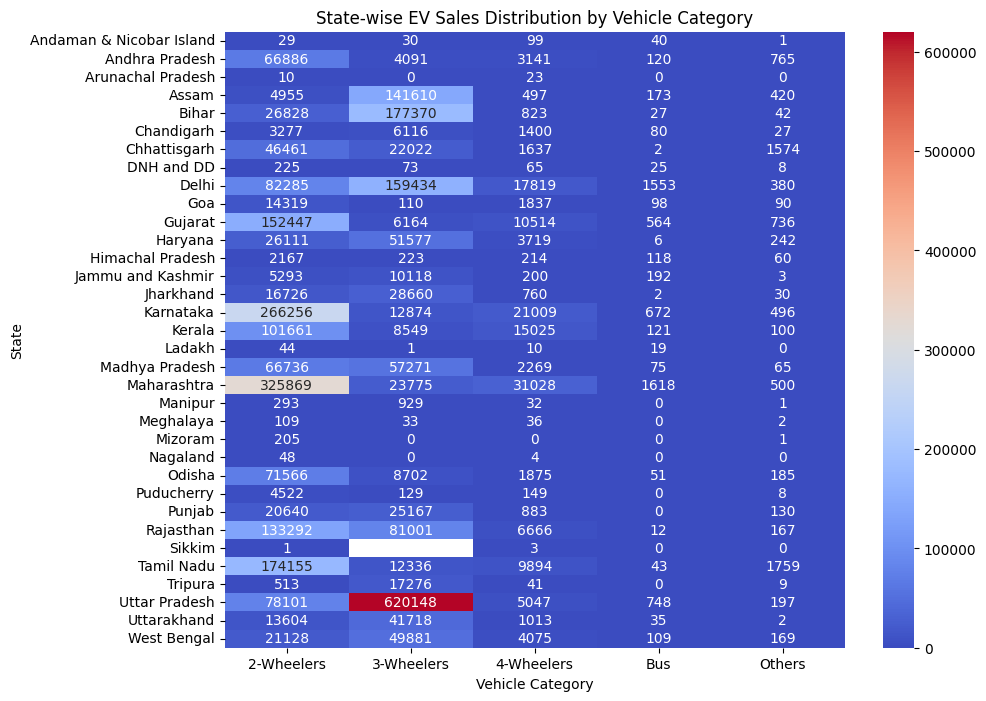

In [97]:
pivot = saledf.pivot_table(
    values='EV_Sales_Quantity',
    index='State',
    columns='Vehicle_Category',
    aggfunc='sum'
)

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt="0.0f")

plt.title('State-wise EV Sales Distribution by Vehicle Category')
plt.xlabel('Vehicle Category')
plt.ylabel('State')

EV sales patterns differ significantly across states, with Uttar Pradesh leading in 3-wheeler adoption, indicating strong commercial usage, while states like Maharashtra, Karnataka, and Tamil Nadu show higher demand for 2-wheelers. Overall, EV adoption remains concentrated in low-cost and utility-driven vehicle categories.

**Feature engineering**



In [98]:
saledf.describe(include='object')

,Month_Name,State,Vehicle_Class,Vehicle_Category,Vehicle_Type
count,95985,95985,95985,95985,95985
unique,12,34,73,5,12
top,mar,Maharashtra,MOTOR CAR,Others,Others
freq,8435,4869,4077,53955,53955


In [99]:
saledf = saledf.drop(['Vehicle_Class'],axis=1)

I had remove the Vehicle_Class since i have Vehicle_Category	and Vehicle_Type which have less Unique values

In [100]:
saledf.head()

,Year,Month_Name,Date,State,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014,jan,2014-01-01,Andhra Pradesh,Others,Others,0
1,2014,jan,2014-01-01,Andhra Pradesh,Others,Others,0
2,2014,jan,2014-01-01,Andhra Pradesh,Others,Others,0
3,2014,jan,2014-01-01,Andhra Pradesh,Others,Others,0
4,2014,jan,2014-01-01,Andhra Pradesh,Bus,Bus,0


In [101]:
saledf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95985 entries, 0 to 96844
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               95985 non-null  int64         
 1   Month_Name         95985 non-null  object        
 2   Date               95985 non-null  datetime64[ns]
 3   State              95985 non-null  object        
 4   Vehicle_Category   95985 non-null  object        
 5   Vehicle_Type       95985 non-null  object        
 6   EV_Sales_Quantity  95985 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 5.9+ MB


Seprating the data for ML_model

In [102]:
# dataset for ML
saledf.insert(2, 'Month', saledf['Date'].dt.month)
ml_data = saledf[['Year','Month','State','Vehicle_Category', 'Vehicle_Type' ,'EV_Sales_Quantity']]

ml_data.to_csv("ev_sales_ml.csv", index=False)

**Conclusion**

The analysis reveals that EV adoption in India is rapidly increasing, with significant growth observed after 2021. Sales are highly concentrated in a few key states such as Uttar Pradesh, Maharashtra, and Karnataka because of the population and infrastructure. The market is primarily dominated by 2-wheelers and 3-wheelers, reflecting strong demand in affordable and last-mile mobility segments. Additionally, EV sales show clear seasonal trends, with peak demand during the festive quarter (October–December). While higher-end segments like 4-wheelers and buses have low adoption, they present significant growth opportunities for the future.